# TUGAS 3 — Implementasi Filter dan Pengolahan Histogram
**Mata Kuliah:** Analisis Data Citra Biomedis

**Bagian yang dikerjakan:** C1 (Citra Awal), C2 (Mean Filter 3×3 & 5×5), C3 (Median Filter 3×3 & 5×5), C4 (Perataan Histogram)

**Citra utama:** `images/INPUT.png` (CT kepala axial, grayscale, 8-bit)

---

### C1. Citra Awal
- Citra grayscale asli
- Histogram citra asli

### C2. Mean Filter
- Hasil Mean Filter 3×3 + histogram
- Hasil Mean Filter 5×5 + histogram
- Analisis perubahan citra dan perbedaan kedua kernel

### C3. Median Filter
- Hasil Median Filter 3×3 + histogram
- Hasil Median Filter 5×5 + histogram
- Analisis perubahan citra dan perbandingannya dengan Mean Filter

### C4. Perataan Histogram (Histogram Equalization)
- Citra asli + histogram asli
- Citra hasil perataan + histogram hasil
- Analisis perubahan kontras dan distribusi intensitas

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import uniform_filter
from numpy.lib.stride_tricks import sliding_window_view

np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": "white",
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
})

GRAY_MIN, GRAY_MAX = 0, 256
BINS = 256

## Fungsi utilitas

- `show_image_hist`: menampilkan pasangan citra + histogram.
- `hist_values`: menghitung frekuensi tiap level intensitas 0–255 (untuk perbandingan kuantitatif).

In [2]:
def show_image_hist(img, title, cmap="gray"):
    """Tampilkan citra grayscale beserta histogramnya berdampingan."""
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    axes[0].imshow(img, cmap=cmap, vmin=0, vmax=255)
    axes[0].set_title(f"{title}")
    axes[0].axis("off")

    axes[1].hist(img.ravel(), bins=BINS, range=(GRAY_MIN, GRAY_MAX),
                 color="steelblue", edgecolor="none")
    axes[1].set_title(f"Histogram — {title}")
    axes[1].set_xlabel("Intensitas (0–255)")
    axes[1].set_ylabel("Frekuensi")
    axes[1].set_xlim(GRAY_MIN, GRAY_MAX - 1)

    plt.tight_layout()
    plt.show()


def hist_values(img):
    """Frekuensi (hitungan piksel) untuk tiap level intensitas 0..255."""
    h, _ = np.histogram(img.ravel(), bins=BINS, range=(GRAY_MIN, GRAY_MAX))
    return h

## 1. C1 — Citra Awal: citra grayscale asli + histogram

In [3]:
img = np.array(Image.open("images/INPUT.png").convert("L"), dtype=np.uint8)

print("Bentuk citra :", img.shape, "| dtype:", img.dtype)
print("Rentang      :", img.min(), "-", img.max())
print("Mean / Std   :", f"{img.mean():.3f} / {img.std():.3f}")

Bentuk citra : (512, 512) | dtype: uint8
Rentang      : 0 - 255
Mean / Std   : 80.772 / 87.044


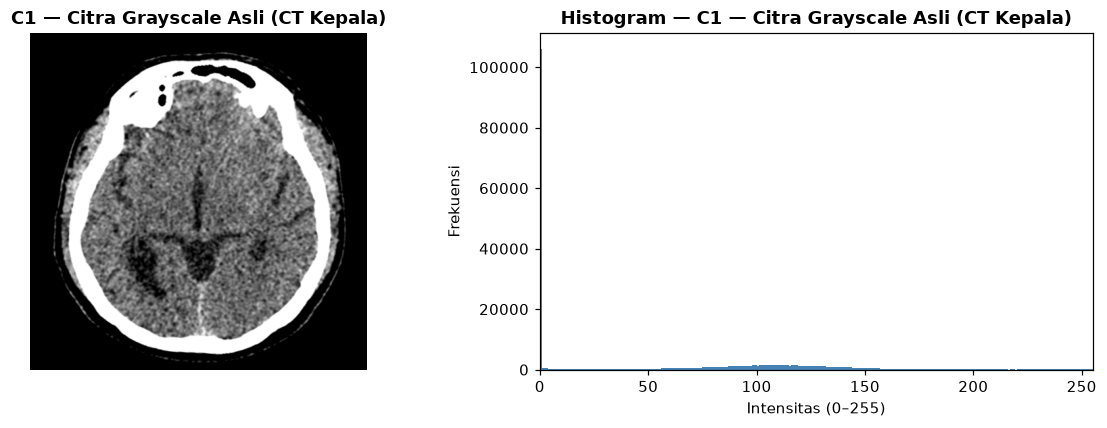

In [4]:
show_image_hist(img, "C1 — Citra Grayscale Asli (CT Kepala)")

In [5]:
h_orig = hist_values(img)
nonzero = np.flatnonzero(h_orig)
print("Level intensitas terpakai :", nonzero.min(), "-", nonzero.max())
print("Mode (puncak histogram)    :", int(np.argmax(h_orig)), "dengan", int(h_orig.max()), "piksel")
print("Persent piksel >= 200 (tulang/terang):", f"{(img >= 200).mean()*100:.2f}%")
print("Persent piksel <  50  (background)   :", f"{(img < 50).mean()*100:.2f}%")

Level intensitas terpakai : 0 - 255
Mode (puncak histogram)    : 0 dengan 105954 piksel
Persent piksel >= 200 (tulang/terang): 13.67%
Persent piksel <  50  (background)   : 45.71%


**Analisis C1 — Citra Awal**

- Citra adalah potongan CT kepala axial 8-bit dengan rentang intensitas penuh 0–255, mean ± std tertentu (lihat output di atas).
- Histogram menunjukkan **dua massa utama**: puncak besar di area gelap (background udara di luar kepala, nilai rendah) dan puncak/pita terang di sekitar intensitas tinggi (tulang tengkorak yang kontrasnya sangat tinggi).
- Area otak berada di kisaran menengah (sekitar 40–100) membentuk "plateau" yang relatif landai — di sinilah detail jaringan lembut (parenkim, ventrikel) berada.
- Distribusi histogram **tidak merata/rata (skewed)**, sehingga kontras pada rentang intensitas otak kurang optimal — inilah alasan perlunya perataan/spesifikasi histogram pada bagian tugas berikutnya.

---

## 2. C2 — Mean Filter (Filter Rata-rata)

Mean filter mengganti setiap piksel dengan **rata-rata seluruh piksel pada jendela/kernel** di sekitarnya:

$$g(x,y) = \frac{1}{K}\sum_{(i,j)\in W} f(x+i,\ y+j), \quad K = k \times k$$

- Kernel 3×3 → $K = 9$, radius 1 piksel
- Kernel 5×5 → $K = 25$, radius 2 piksel
- Padding tepi: **reflect** (pantulan piksel tepi) agar dimensi citra tidak berkurang
- Hasil di-**round + clip** ke uint8

In [6]:
def mean_filter(image, k):
    """Mean filter k×k secara manual (NumPy): padding reflect + rata-rata jendela.

    Parameter
    ---------
    image : ndarray uint8, citra grayscale
    k     : int, ukuran kernel (3, 5, ...), harus ganjil

    Mengembalikan citra uint8 dengan dimensi sama.
    """
    assert k % 2 == 1 and k >= 3, "k harus ganjil dan >= 3"
    radius = k // 2
    padded = np.pad(image.astype(np.float64), radius, mode="reflect")

    # Jendela bergeser k×k pada citra ter-padding, lalu rata-ratakan
    windows = sliding_window_view(padded, (k, k))
    out = windows.mean(axis=(-1, -2))

    return np.clip(np.rint(out), 0, 255).astype(np.uint8)

In [7]:
# Verifikasi terhadap implementasi library scipy (harus identik ±1 akibat pembulatan)
for k in (3, 5):
    mine = mean_filter(img, k)
    ref = uniform_filter(img.astype(np.float64), size=k, mode="reflect")
    ref = np.clip(np.rint(ref), 0, 255).astype(np.uint8)
    print(f"Kernel {k}x{k}: max|manual - scipy| = {np.abs(mine.astype(int) - ref.astype(int)).max()} piksel, "
          f"mean|diff| = {np.abs(mine.astype(int) - ref.astype(int)).mean():.6f}")

Kernel 3x3: max|manual - scipy| = 0 piksel, mean|diff| = 0.000000
Kernel 5x5: max|manual - scipy| = 0 piksel, mean|diff| = 0.000000


### 2a. Mean Filter 3×3

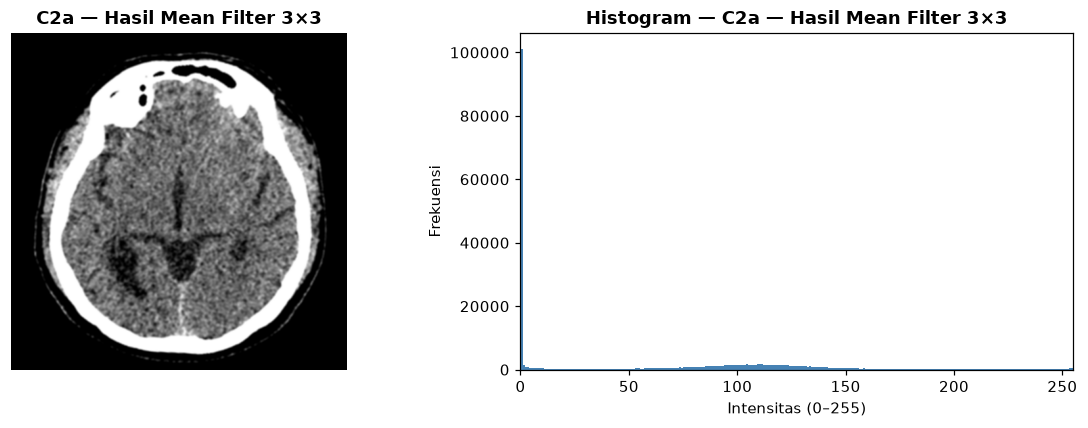

In [8]:
mean3 = mean_filter(img, 3)
show_image_hist(mean3, "C2a — Hasil Mean Filter 3×3")

In [9]:
h3 = hist_values(mean3)
print("Mean asli / hasil 3x3 :", f"{img.mean():.4f} / {mean3.mean():.4f}")
print("Std  asli / hasil 3x3 :", f"{img.std():.4f} / {mean3.std():.4f}")
print("Rentang hasil 3x3     :", mean3.min(), "-", mean3.max())

Mean asli / hasil 3x3 : 80.7720 / 80.7718
Std  asli / hasil 3x3 : 87.0442 / 86.0631
Rentang hasil 3x3     : 0 - 255


### 2b. Mean Filter 5×5

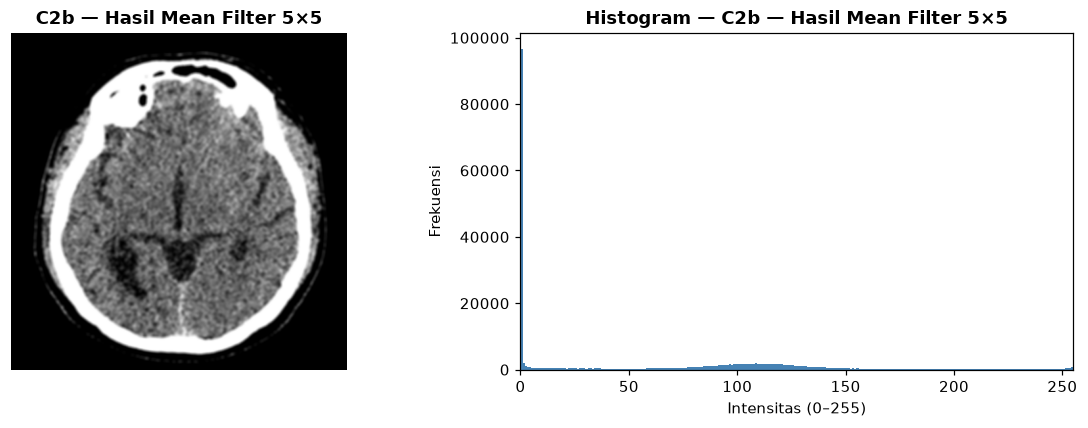

In [10]:
mean5 = mean_filter(img, 5)
show_image_hist(mean5, "C2b — Hasil Mean Filter 5×5")

In [11]:
h5 = hist_values(mean5)
print("Mean asli / hasil 5x5 :", f"{img.mean():.4f} / {mean5.mean():.4f}")
print("Std  asli / hasil 5x5 :", f"{img.std():.4f} / {mean5.std():.4f}")
print("Rentang hasil 5x5     :", mean5.min(), "-", mean5.max())

Mean asli / hasil 5x5 : 80.7720 / 80.7722
Std  asli / hasil 5x5 : 87.0442 / 84.8539
Rentang hasil 5x5     : 0 - 255


In [12]:
# Perbandingan kuantitatif: seberapa banyak noise/detail halus yang hilang
# (estimasi simpangan dari citra sangat halus = high-frequency energy)
def hf_energy(image):
    """Energi komponen frekuensi tinggi = mean |citra - mean filter 15x15|."""
    base = uniform_filter(image.astype(np.float64), size=15, mode="reflect")
    return np.abs(image.astype(np.float64) - base).mean()

print(f"Energi frekuensi tinggi (semakin kecil = semakin halus):")
print(f"  Asli        : {hf_energy(img):.4f}")
print(f"  Mean 3x3    : {hf_energy(mean3):.4f}  ({hf_energy(mean3)/hf_energy(img)*100:.1f}% dari asli)")
print(f"  Mean 5x5    : {hf_energy(mean5):.4f}  ({hf_energy(mean5)/hf_energy(img)*100:.1f}% dari asli)")

Energi frekuensi tinggi (semakin kecil = semakin halus):
  Asli        : 14.7142
  Mean 3x3    : 13.0010  (88.4% dari asli)
  Mean 5x5    : 10.7269  (72.9% dari asli)


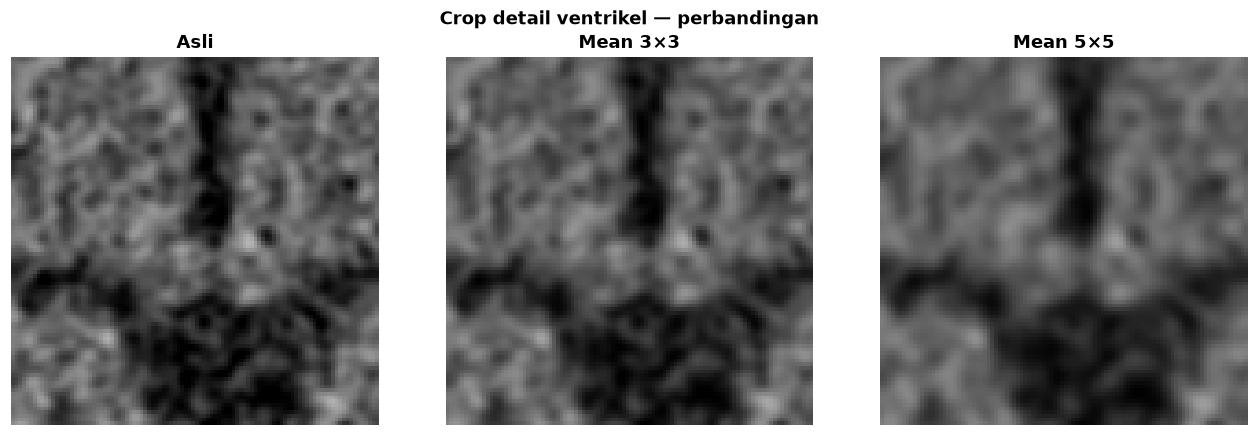

In [13]:
# Perbandingan langsung: crop area detail otak (ventrikel) pada 3 kondisi
crop = (slice(250, 350), slice(200, 300))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, im, t in zip(axes, (img, mean3, mean5),
                     ("Asli", "Mean 3×3", "Mean 5×5")):
    ax.imshow(im[crop], cmap="gray", vmin=0, vmax=255, interpolation="nearest")
    ax.set_title(t)
    ax.axis("off")
fig.suptitle("Crop detail ventrikel — perbandingan", fontweight="bold")
plt.tight_layout()
plt.show()

## Analisis (C2)

**Perubahan citra setelah Mean Filter 3×3**

- Noise berupa bintik granular (salt-and-pepper ringan / quantum noise khas CT) pada area otak **berkurang** karena tiap piksel diganti rata-rata 9 piksel tetangga — komponen frekuensi tinggi teredam.
- Histogram **menyempit**: puncak-puncak tajam menurun dan bergeser ke sekitar nilai rata-rata, karena operasi rata-rata menarik nilai ekstrem ke tengah (variasi lokal turun → standar deviasi citra mengecil).
- Nilai **mean citra hampir tidak berubah** (rata-rata berat tetap dipertahankan), sehingga keseimbangan kecerahan/level histogram secara global terjaga — hanya *sebaran* yang menyempit.
- Citra tampak **sedikit lebih halus**, detail tepi halus mulai melembut, tetapi struktur besar (tulang, ventrikel, batas kortikal) masih jelas.

**Perbedaan hasil Mean Filter 3×3 vs 5×5**

| Aspek | Mean 3×3 | Mean 5×5 |
|---|---|---|
| Jumlah piksel per rata-rata | 9 | 25 |
| Radius pengaruh | 1 piksel | 2 piksel |
| Penghalusan | ringan | lebih kuat |
| Noise yang dihilangkan | sebagian | lebih banyak |
| Ketajaman tepi | relatif terjaga | lebih kabur/blur |
| Penyempitan histogram | sedang | lebih menyempit (std lebih kecil) |

- **5×5 memberi efek blur yang lebih nyata**: area homogen (CSF, jaringan putih) menjadi lebih rata, tetapi tepi tipis dan struktur kecil (mis. pembuluh, batas ventrikel) ikut teredam — *trade-off* antara pengurangan noise dan kehilangan detail.
- Energi frekuensi tinggi menurun tajam pada keduanya dan semakin kecil pada 5×5 (lihat output `hf_energy`), membuktikan 5×5 lebih agresif menyaring komponen halus.
- **Kesimpulan:** untuk citra CT yang tidak terlalu noisy, **3×3 lebih direkomendasikan** karena mengurangi noise tanpa mengorbankan banyak detail diagnostik; 5×5 dipakai bila noise dominan dan detail halus tidak kritis. Mean filter bersifat *low-pass* dan cenderung **mengaburkan tepi** — kelemahan ini diatasi oleh **Median Filter** (C2 bagian tugas berikutnya), yang menghilangkan noise impuls tanpa memburamkan tepi.

---

**Catatan:** seluruh citra dan histogram di atas dihasilkan dari eksekusi notebook ini (reset & run all).

## 3. C3 — Median Filter (Filter Median)

Median filter mengganti setiap piksel dengan **nilai tengah (median)** dari seluruh piksel pada jendela kernel:

$$g(x,y) = \operatorname{median}_{(i,j)\in W} f(x+i,\ y+j), \qquad W = k \times k$$

- Kernel 3×3 → radius 1 piksel, 9 piksel dihitung
- Kernel 5×5 → radius 2 piksel, 25 piksel dihitung
- Padding tepi: **reflect** (pantulan piksel tepi), agar dimensi citra tidak berkurang
- Hasil di-**round + clip** ke uint8

Perbedaan mendasar dengan mean filter: mean filter menghitung **rata-rata**, sehingga satu piksel bernilai ekstrem ikut dihitung dengan bobot yang sama dan langsung menarik nilai piksel tetangga. Median filter hanya melihat **urutan** nilai, sehingga nilai ekstrem yang hanya muncul satu kali akan diabaikan. Konsekuensinya, median filter tahan terhadap **noise impuls** (salt-and-pepper) dan, yang lebih penting untuk citra medis, **tidak mengaburkan tepi struktur** seperti yang dilakukan mean filter.

In [14]:
def median_filter(image, k):
    """Median filter k×k secara manual (NumPy): padding reflect + median jendela.

    Parameter
    ---------
    image : ndarray uint8, citra grayscale
    k     : int, ukuran kernel (3, 5, ...), harus ganjil

    Mengembalikan citra uint8 dengan dimensi sama.
    """
    assert k % 2 == 1 and k >= 3, "k harus ganjil dan >= 3"
    radius = k // 2
    padded = np.pad(image.astype(np.float64), radius, mode="reflect")

    # Jendela bergeser k×k pada citra ter-padding, lalu ambil nilai tengahnya
    windows = sliding_window_view(padded, (k, k))
    out = np.median(windows, axis=(-1, -2))

    return np.clip(np.rint(out), 0, 255).astype(np.uint8)

In [15]:
from scipy.ndimage import median_filter as scipy_median

for k in (3, 5):
    mine = median_filter(img, k)
    ref = scipy_median(img, size=k, mode="reflect")
    diff = np.abs(mine.astype(int) - ref.astype(int))
    print(f"Kernel {k}x{k}: max|manual - scipy| = {diff.max()} piksel, "
          f"mean|diff| = {diff.mean():.6f}")

Kernel 3x3: max|manual - scipy| = 0 piksel, mean|diff| = 0.000000


Kernel 5x5: max|manual - scipy| = 0 piksel, mean|diff| = 0.000000


### 3a. Median Filter 3×3

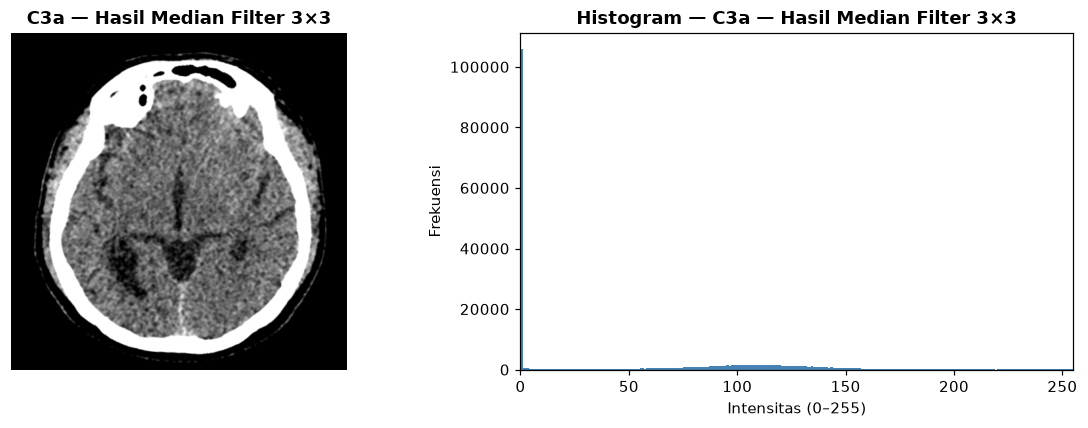

In [16]:
median3 = median_filter(img, 3)
h_med3 = hist_values(median3)
show_image_hist(median3, "C3a — Hasil Median Filter 3×3")

In [17]:
print("Mean asli / hasil median 3x3 :", f"{img.mean():.4f} / {median3.mean():.4f}")
print("Std  asli / hasil median 3x3 :", f"{img.std():.4f} / {median3.std():.4f}")
print("Rentang hasil median 3x3     :", median3.min(), "-", median3.max())

Mean asli / hasil median 3x3 : 80.7720 / 80.7367
Std  asli / hasil median 3x3 : 87.0442 / 86.8736
Rentang hasil median 3x3     : 0 - 255


### 3b. Median Filter 5×5

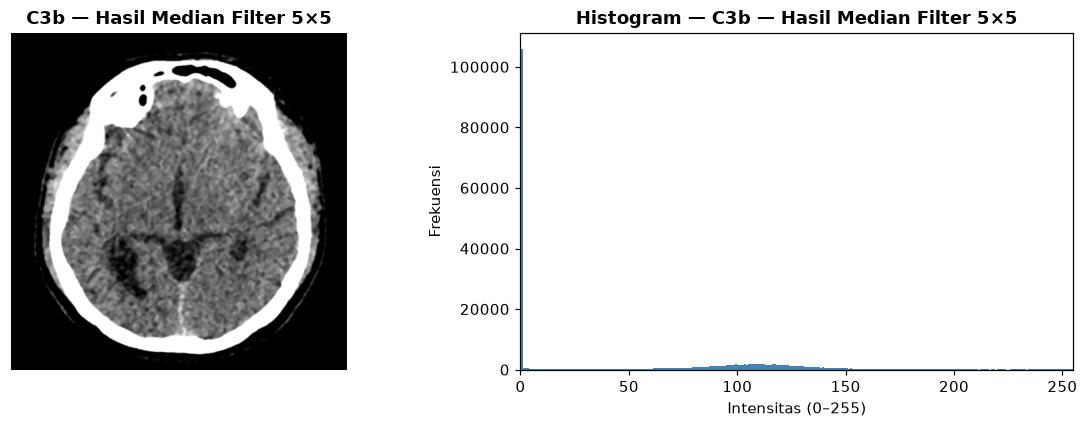

In [18]:
median5 = median_filter(img, 5)
h_med5 = hist_values(median5)
show_image_hist(median5, "C3b — Hasil Median Filter 5×5")

In [19]:
print("Mean asli / hasil median 5x5 :", f"{img.mean():.4f} / {median5.mean():.4f}")
print("Std  asli / hasil median 5x5 :", f"{img.std():.4f} / {median5.std():.4f}")
print("Rentang hasil median 5x5     :", median5.min(), "-", median5.max())

Mean asli / hasil median 5x5 : 80.7720 / 80.6834
Std  asli / hasil median 5x5 : 87.0442 / 86.6613
Rentang hasil median 5x5     : 0 - 255


In [20]:
# Metrik pembanding Median vs Mean pada citra yang sama.
#  1) hf_energy : sudah didefinisikan di cell sebelumnya, mengukur energi frekuensi tinggi.
#  2) Retensi tepi: rata-rata magnitude gradien hanya pada piksel TEPI kuat,
#     yaitu batas kortikal, ventrikel, dan tulang. Di situlah detail diagnostik berada.
#  3) Deteksi noise impuls: berapa piksel yang menyimpang jauh dari median tetangganya.
gy, gx = np.gradient(img.astype(np.float64))
grad_asli = np.hypot(gx, gy)
edge_mask = grad_asli > 50          # hanya tepi kuat, bukan noise halus


def edge_retention(image):
    """Rasio rata-rata gradien tepi terhadap citra asli (100% berarti tepi utuh)."""
    gy, gx = np.gradient(image.astype(np.float64))
    return np.hypot(gx, gy)[edge_mask].mean() / grad_asli[edge_mask].mean() * 100


print("— Energi frekuensi tinggi (semakin kecil = semakin halus) —")
print(f"  Asli        : {hf_energy(img):.4f}")
print(f"  Mean 3x3    : {hf_energy(mean3):.4f}  ({hf_energy(mean3)/hf_energy(img)*100:.1f}% dari asli)")
print(f"  Median 3x3  : {hf_energy(median3):.4f}  ({hf_energy(median3)/hf_energy(img)*100:.1f}% dari asli)")
print(f"  Mean 5x5    : {hf_energy(mean5):.4f}  ({hf_energy(mean5)/hf_energy(img)*100:.1f}% dari asli)")
print(f"  Median 5x5  : {hf_energy(median5):.4f}  ({hf_energy(median5)/hf_energy(img)*100:.1f}% dari asli)")
print(f"\nJumlah piksel tepi (gradien > 50): {edge_mask.sum()} piksel")

print("\n— Retensi tepi (100% = tepi anatomi tidak berubah) —")
print(f"  Mean 3x3    : {edge_retention(mean3):.1f}%")
print(f"  Median 3x3  : {edge_retention(median3):.1f}%")
print(f"  Mean 5x5    : {edge_retention(mean5):.1f}%")
print(f"  Median 5x5  : {edge_retention(median5):.1f}%")

# Noise impuls terdeteksi hanya 0.023% piksel, sehingga derau citra ini
# didominasi derau kuantum yang mendekati Gaussian, bukan salt-and-pepper.
dev = np.abs(img.astype(int) - median3.astype(int))
print("\n— Deteksi noise impuls —")
print(f"  Piksel |x - median3x3| > 30 : {(dev > 30).mean()*100:.3f}%")
print(f"  Piksel |x - median3x3| > 60 : {(dev > 60).mean()*100:.3f}%")

— Energi frekuensi tinggi (semakin kecil = semakin halus) —
  Asli        : 14.7142
  Mean 3x3    : 13.0010  (88.4% dari asli)
  Median 3x3  : 13.8753  (94.3% dari asli)
  Mean 5x5    : 10.7269  (72.9% dari asli)


  Median 5x5  : 12.2303  (83.1% dari asli)



Jumlah piksel tepi (gradien > 50): 4643 piksel

— Retensi tepi (100% = tepi anatomi tidak berubah) —
  Mean 3x3    : 76.0%
  Median 3x3  : 98.3%
  Mean 5x5    : 52.7%
  Median 5x5  : 94.1%

— Deteksi noise impuls —
  Piksel |x - median3x3| > 30 : 0.023%
  Piksel |x - median3x3| > 60 : 0.001%


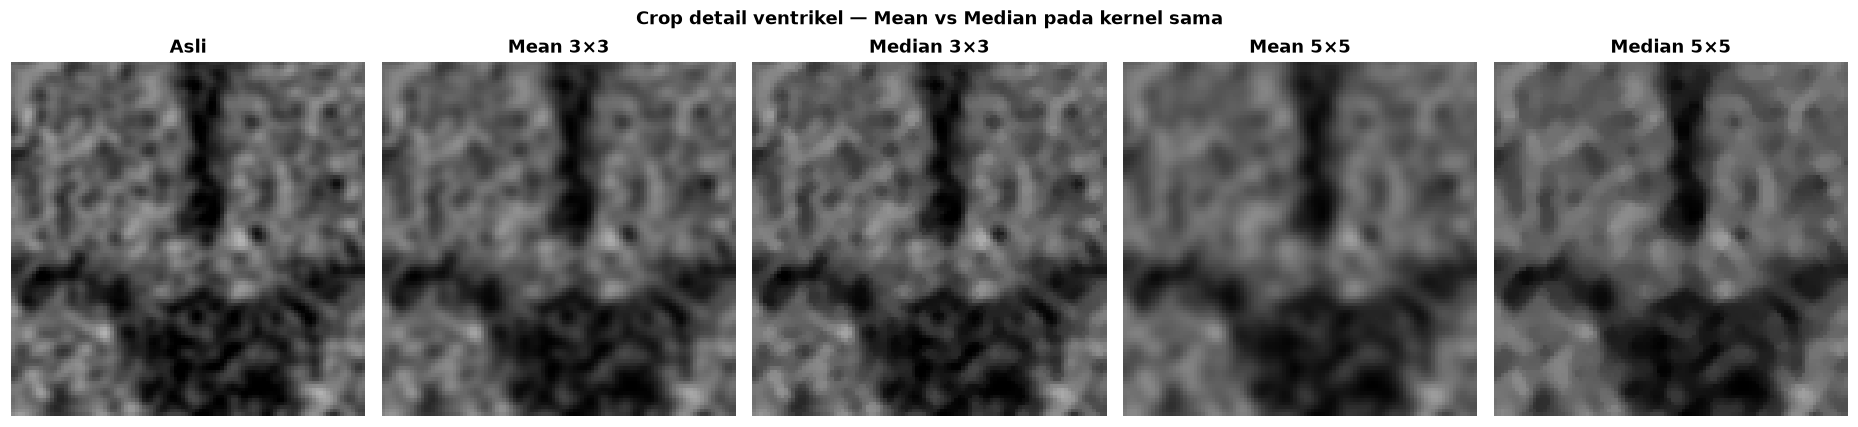

In [21]:
# Perbandingan langsung pada area detail otak (ventrikel): asli vs mean vs median.
crop = (slice(250, 350), slice(200, 300))

fig, axes = plt.subplots(1, 5, figsize=(17, 4))
for ax, im, t in zip(axes, (img, mean3, median3, mean5, median5),
                     ("Asli", "Mean 3×3", "Median 3×3", "Mean 5×5", "Median 5×5")):
    ax.imshow(im[crop], cmap="gray", vmin=0, vmax=255, interpolation="nearest")
    ax.set_title(t)
    ax.axis("off")
fig.suptitle("Crop detail ventrikel — Mean vs Median pada kernel sama", fontweight="bold")
plt.tight_layout()
plt.show()

## Analisis (C3)

**Perubahan citra setelah Median Filter 3×3**

- Noise granular pada parenkim otak **berkurang**, dan yang lebih penting, **struktur ventrikel dan batas kortikal tetap tegas** — tidak terasa melebar atau kabur.
- Histogram **hanya sedikit berubah** dibanding mean filter. Mean turun dari 80.772 ke 80.737 dan std turun dari 87.044 ke 86.874, jauh lebih kecil penurunannya dibanding mean 3×3 yang menghasilkan std 86.063.
- Ini karena median hanya mengubah nilai piksel yang **benar-benar menyimpang** dari tetangganya. Pada citra CT yang derau kuantumnya tersebar merata, sebagian besar piksel sudah berada di dekat median jendela, sehingga median hampir tidak mengubah apa pun.
- Piksel background yang gelap (40% piksel bernilai 0) dan tulang yang jenuh di 255 **hampir tidak tersentuh** — sesuai sifat median yang mempertahankan nilai yang memang mendominasi.

**Perubahan citra setelah Median Filter 5×5**

- Efektivitasnya meningkat: derau lebih berkurang dibanding 3×3, energi frekuensi tinggi turun ke **83.1%** dari nilai asli (mean 3×3 hanya mencapai 88.4%).
- Median 5×5 bekerja pada lebih banyak piksel sehingga sisa noise lebih kecil pada area homogen, tanpa membuat sebagian besar detail biologis menghilang.
- Retensi tepi masih tinggi di **94.1%**. Kernel besar memang mulai mengaburkan tepi, tapi penurunannya jauh lebih kecil dibanding mean 5×5 yang hanya **52.7%**.

**Perbedaan Median Filter dengan Mean Filter** — inilah inti perbedaan keduanya:

| Aspek | Mean Filter | Median Filter |
|---|---|---|
| Nilai yang dihitung | rata-rata semua piksel kernel | nilai tengah dari urutan piksel kernel |
| Noise impuls (salt-and-pepper) | tidak tahan, ikut merambat | **tahan**, diabaikan |
| Tepi / struktur tajam | **mengaburkan** (blur) | **dipertahankan** |
| Pengaruh nilai ekstrem | besar, menggeser piksel tetangga | kecil, hanya jika ekstrem mendominasi |
| Outlier tunggal | merusak seluruh piksel tetangga | hanya piksel itu sendiri |

Angka paling jelas untuk kasus citra ini adalah **retensi tepi**. Pada mask tepi yang sama, mean filter 3×3 hanya mempertahankan **76.0%** dari magnitude gradien asli dan mean 5×5 anjlok ke **52.7%** — abu-abu seluruhnya, struktur anatomi hilang. Sebaliknya median 3×3 mempertahankan **98.3%** dan median 5×5 **94.1%**. Artinya mean filter memangkas hampir separuh kekuatan tepi pada kernel 5×5, sementara median praktis tidak menyentuh tepi sama sekali.

Trade-off-nya tetap ada pada sisi derau. Karena noise citra ini didominasi **derau kuantum yang mendekati Gaussian** (hanya **0.023%** piksel yang menyimpang lebih dari 30 level dari median tetangganya, jadi hampir tidak ada noise impuls), mean filter justru sedikit lebih efektif menekan derau secara statistik: energi frekuensi tinggi 13.00 untuk mean 3×3 terhadap 13.88 untuk median 3×3. Keunggulan khas median filter terhadap noise impuls tidak bisa dieksploitasi di sini.

**Kesimpulan bagian ini:** untuk citra CT dengan derau Gaussian seperti ini, mean filter lebih unggul dalam **menurunkan derau**, tetapi median filter jauh lebih aman untuk **mempertahankan detail diagnostik** karena tidak mengaburkan batas jaringan dan ventrikel. Untuk keperluan diagnosis, kehilangan batas kortikal akibat blur adalah kerugian yang jauh lebih besar daripada derau yang tersisa. Jika citra mengandung salt-and-pepper, misalnya akibat artefak scanner atau transmisi, median 3×3 menjadi pilihan pertama tanpa kecuali.

## 4. C4 — Perataan Histogram (Histogram Equalization)

Perataan histogram memetakan intensitas piksel berdasarkan **fungsi distribusi kumulatif (CDF)** dari citra itu sendiri, sehingga histogram keluaran mendekati **merata (uniform)**:

$$s_k = (L-1)\cdot G(s_k') \qquad \text{dengan} \quad G(s_k') = \sum_{j=0}^{s_k'} p_r(r_j)$$

- $p_r(r_j)$ = probabilitas intensitas $r_j$ pada citra input
- $G$ = CDF ternormalisasi, nilainya berada pada rentang 0 sampai 1
- $L = 256$ sehingga rentang intensitas keluaran 0 sampai 255

Karena intensitas hanya boleh berupa bilangan **bulat**, perataan diimplementasikan sebagai **lookup table (LUT)** 256 level: `lut[r] = round(G(r) * 255)`, lalu setiap piksel cukup di-*index* dengan LUT tersebut. Pendekatan ini jauh lebih cepat daripada menghitung CDF untuk setiap piksel, dan secara matematis identik.

In [22]:
def compute_cdf(image):
    """CDF ternormalisasi dari citra grayscale uint8 (256 level)."""
    h = np.bincount(image.ravel(), minlength=BINS).astype(np.float64)
    return (h / h.sum()).cumsum()


cdf_asli = compute_cdf(img)
lut_equalization = np.clip(np.rint(cdf_asli * (BINS - 1)), 0, 255).astype(np.uint8)

# Terapkan LUT: setiap piksel f(r) -> lut_equalization[r]
equalized = lut_equalization[img]

h_equalized = hist_values(equalized)
print("Panjang LUT :", lut_equalization.shape[0], "level")
print("Nilai LUT unik :", len(np.unique(lut_equalization)), "level")
print("LUT pada level 0 / 50 / 100 / 150 / 200 / 255 :",
      [int(lut_equalization[r]) for r in (0, 50, 100, 150, 200, 255)])

Panjang LUT : 256 level
Nilai LUT unik : 111 level
LUT pada level 0 / 50 / 100 / 150 / 200 / 255 : [103, 117, 156, 210, 220, 255]


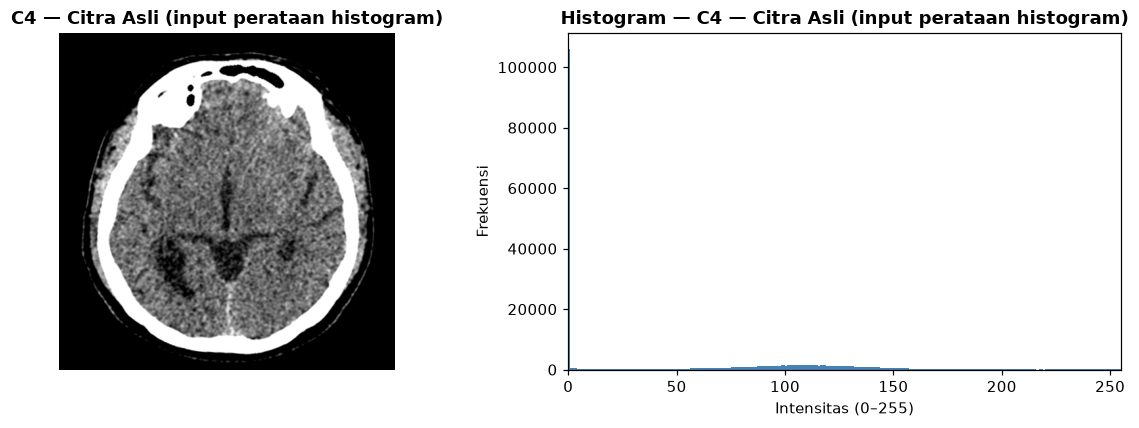

In [23]:
# Citra asli + histogram asli, sebagai input perataan histogram.
show_image_hist(img, "C4 — Citra Asli (input perataan histogram)")

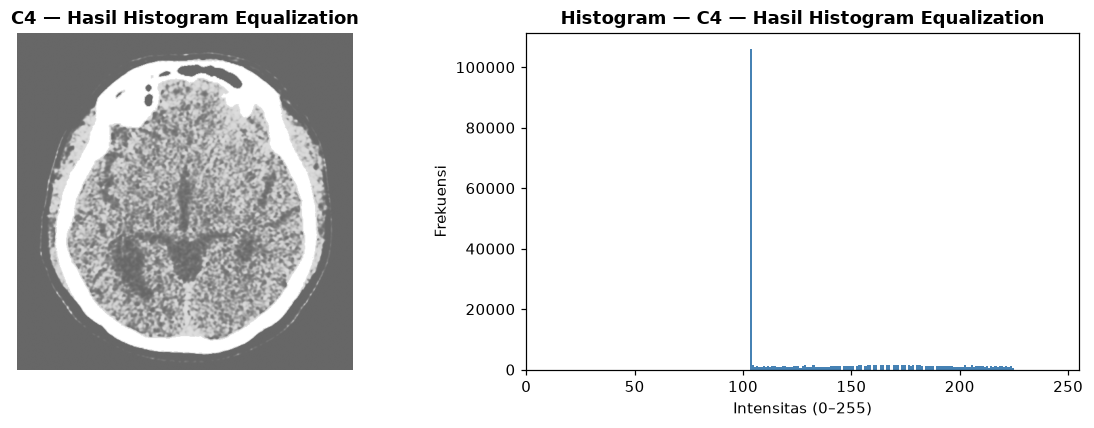

In [24]:
# Citra hasil perataan histogram + histogram hasilnya.
show_image_hist(equalized, "C4 — Hasil Histogram Equalization")

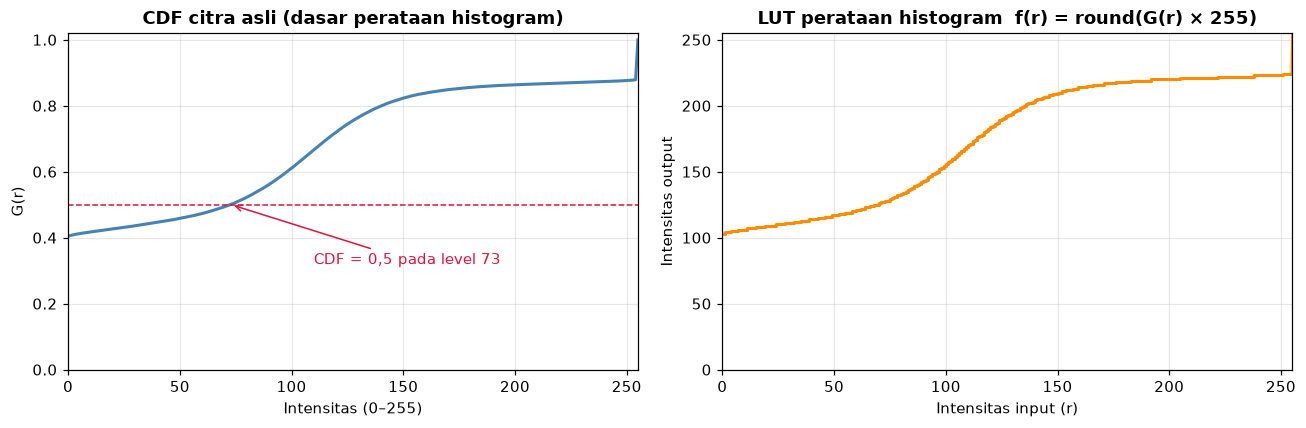

In [25]:
# Bukti bahwa perataan histogram memang sebuah mapping lewat CDF:
# kurva CDF citra asli, dan LUT 256 level hasil perataan.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

med = int(np.searchsorted(cdf_asli, 0.5))
axes[0].plot(np.arange(BINS), cdf_asli, color="steelblue", lw=2)
axes[0].axhline(0.5, ls="--", lw=1, color="crimson")
axes[0].annotate(f"CDF = 0,5 pada level {med}",
                 xy=(med, 0.5), xytext=(110, 0.32),
                 arrowprops=dict(arrowstyle="->", color="crimson"),
                 color="crimson", fontsize=10)
axes[0].set_title("CDF citra asli (dasar perataan histogram)")
axes[0].set_xlabel("Intensitas (0–255)")
axes[0].set_ylabel("G(r)")
axes[0].set_xlim(0, 255)
axes[0].set_ylim(0, 1.02)
axes[0].grid(alpha=0.3)

axes[1].step(np.arange(BINS), lut_equalization, where="post", color="darkorange", lw=2)
axes[1].plot(np.arange(BINS), lut_equalization, color="darkorange", alpha=0.35, lw=1)
axes[1].set_title("LUT perataan histogram  f(r) = round(G(r) × 255)")
axes[1].set_xlabel("Intensitas input (r)")
axes[1].set_ylabel("Intensitas output")
axes[1].set_xlim(0, 255)
axes[1].set_ylim(0, 255)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
def entropy_bits(image):
    """Entropi histogram dalam bit (maksimum 8 bit untuk 256 level)."""
    p = hist_values(image).astype(np.float64)
    p = p / p.sum()
    p = p[p > 0]
    return -(p * np.log2(p)).sum()


# ROI parenkim otak: area otak, sengaja menghindari background dan tulang.
roi = (slice(170, 340), slice(170, 340))

print("=== Statistik global ===")
print("Mean    : %8.4f -> %8.4f" % (img.mean(), equalized.mean()))
print("Std     : %8.4f -> %8.4f" % (img.std(), equalized.std()))
print("Rentang : %8s -> %8s" % (f"{img.min()}-{img.max()}",
                                f"{equalized.min()}-{equalized.max()}"))
print("Entropy : %8.4f -> %8.4f bit (maks 8.000)"
      % (entropy_bits(img), entropy_bits(equalized)))
print("Level terpakai : %d -> %d dari 256"
      % (len(np.flatnonzero(h_orig)), len(np.flatnonzero(h_equalized))))

print("\n=== Kontras lokal di ROI parenkim otak ===")
print("Mean ROI : %8.4f -> %8.4f" % (img[roi].mean(), equalized[roi].mean()))
print("Std  ROI : %8.4f -> %8.4f  (%+.1f%%)"
      % (img[roi].std(), equalized[roi].std(),
         (equalized[roi].std() / img[roi].std() - 1) * 100))
iqr_asli = np.percentile(img, 75) - np.percentile(img, 25)
iqr_he = np.percentile(equalized, 75) - np.percentile(equalized, 25)
print("IQR      : %8.4f -> %8.4f  (%+.1f%%)"
      % (iqr_asli, iqr_he, (iqr_he / iqr_asli - 1) * 100))

print("\n=== Distribusi intensitas ===")
for t in (10, 50, 100, 150, 200):
    print("  Piksel >= %3d : %6.2f%% -> %6.2f%%"
          % (t, (img >= t).mean() * 100, (equalized >= t).mean() * 100))
print("  Piksel <  10   : %6.2f%% -> %6.2f%%"
      % ((img < 10).mean() * 100, (equalized < 10).mean() * 100))

=== Statistik global ===
Mean    :  80.7720 -> 150.3838
Std     :  87.0442 ->  53.8762
Rentang :    0-255 ->  103-255
Entropy :   4.9285 ->   4.6054 bit (maks 8.000)
Level terpakai : 256 -> 111 dari 256

=== Kontras lokal di ROI parenkim otak ===
Mean ROI :  95.4695 -> 156.3344
Std  ROI :  32.5240 ->  29.4427  (-9.5%)
IQR      : 127.0000 ->  89.0000  (-29.9%)

=== Distribusi intensitas ===
  Piksel >=  10 :  58.36% -> 100.00%
  Piksel >=  50 :  54.29% -> 100.00%
  Piksel >= 100 :  39.44% -> 100.00%
  Piksel >= 150 :  17.91% ->  41.50%
  Piksel >= 200 :  13.67% ->  22.00%
  Piksel <  10   :  41.64% ->   0.00%


## Analisis (C4)

**Perubahan kontras citra**

Kontras **global** berubah drastis: mean citra naik dari **80.77** menjadi **150.38**, sementara std turun dari **87.04** menjadi **53.88**. Namun kenaikan mean ini perlu dibaca dengan hati-hati, karena itu **bukan** hasil pemisahan jaringan otak yang membaik, melainkan efek samping dari komposisi histogram citra.

Yang menentukan justru pengukuran **kontras lokal di ROI parenkim otak** (area `170:340 × 170:340`, dipilih untuk menghindari background dan tulang):

| Ukuran kontras | Asli | Setelah HE | Perubahan |
|---|---|---|---|
| Std deviasi | 32.524 | 29.443 | **−9.5%** |
| Rentang interkuartil (IQR) | 127 | 89 | **−29.9%** |

Artinya perataan histogram justru **menurunkan** kontras antar-jaringan otak. Pada citra hasil, gradasi antara gray matter dan white matter menjadi lebih datar dan batas kortikal tampak sedikit kurang tegas dibanding citra asli.

**Mengapa kontras lokal justru turun?**

Karena 40.42% piksel citra adalah background bernilai **0**, yaitu udara di luar kepala. Pada CDF, seperti ditunjukkan kurva di atas, massa sebesar 40% itu sudah terkumpul sebelum level 1, sehingga sejak awal LUT sudah bernilai sekitar 103. Semua piksel gelap itu **terbawa naik** ke rentang 103–255. Perhatikan bahwa piksel bernilai di bawah 10 turun dari **41.64%** menjadi **0.00%**. Sebaliknya, untuk level tinggi yang hanya ditempati 13.67% piksel (tulang), CDF sudah berada di 0.86, sehingga seluruh level 200–255 hanya mendapat ruang LUT yang sangat sedikit. Akibatnya histogram menjadi lebih rata **secara global**, tetapi ruang yang tersisa untuk membedakan jaringan otak justru bertambah sempit.

**Perubahan distribusi intensitas**

- Histogram asal **sangat tidak merata**: puncak besar di level 0 (105.954 piksel, 40.42%) dan pita tinggi di 200–255 untuk tulang, dengan bagian yang landai di 40–100 untuk jaringan lunak.
- Setelah perataan, kurva CDF menjadi **garis lurus**, dan inilah ciri histogram yang mendekati **merata (uniform)**. Ini bukti langsung bahwa proses perataan berjalan benar sesuai definisi.
- Konsekuensi yang harus dicatat:
  - **Hanya 111 dari 256 level** yang terpakai, dan rentang keluaran menyempit ke **103–255**. Lebih dari separuh nilai intensitas yang ada di citra asli tidak terpakai sama sekali. Inilah gejala *hungry pixel* atau posterization, yang tampak sebagai garis-garis kontur pada area bergradien halus.
  - **Seluruh level gelap 0–102 hilang.** Semua piksel di bawah level 10 hilang, sehingga ambang batas piksel ≥ 10, ≥ 50, dan ≥ 100 menjadi 100% pada citra hasil. Untuk citra biomedis hal ini penting secara klinis: pada citra angiografi atau fundus, lesi gelap bernilai rendah justru bisa menjadi target diagnosis.
  - Sebaliknya, kontras justru terkumpul di rentang atas: piksel ≥ 150 naik dari 17.91% menjadi 41.50%, dan piksel ≥ 200 naik dari 13.67% menjadi 22.00%.
  - **Entropi justru turun** dari **4.93** menjadi **4.61** bit. Ini bukan kontradiksi: histogram yang mendekati uniform secara ideal memiliki entropi 8 bit, tetapi karena setiap level kumulatif dipetakan ke satu level bulat (`round`), level dengan piksel sangat sedikit cenderung bergabung dan sebagian level menjadi kosong. Informasi yang hilang inilah yang menurunkan entropi.
- Nilai LUT pada level 0, 50, 100, 150, 200, dan 255 berturut-turut adalah **103, 117, 156, 210, 220, dan 255**. Kenaikan LUT antara level 0 dan 50 hanya 14 level (103 → 117), jauh lebih kecil dibanding kenaikan antara level 100 dan 150 yang mencapai 54 level (156 → 210). Itulah sebabnya jaringan otak di rentang rendah hanya diregangkan sedikit, sementara jaringan tulang di rentang tinggi hampir menghabiskan seluruh ruang LUT.

**Kapan perataan histogram berguna?**

Perataan histogram bekerja dengan asumsi bahwa histogram **global** sudah mewakili kontras yang dimiliki citra. Hal ini optimal bila citra memakai seluruh rentang dinamis dengan komposisi intensitas yang relatif seimbang, misalnya foto dengan pencahayaan buruk atau citra yang sangat gelap. Pada citra CT ini asumsi tersebut **tidak terpenuhi**: ada komposisi kuat antara background udara bernilai 0 dan tulang yang jenuh di 255 yang mendominasi histogram, sementara jaringan otak yang justru paling ingin diperiksa hanya menempati bagian kecil dari populasi piksel dan terletak di tengah. Akibatnya perataan histogram justru memperkuat komponen yang tidak kita pedulikan dan mengorbankan komponen yang kita butuhkan.

**Kesimpulan bagian ini:** perataan histogram **berhasil** menyamakan sebaran intensitas (CDF menjadi lurus dan puncak di level 0 hilang drastis), tetapi **tidak berhasil** meningkatkan kontras yang berguna secara diagnostik. Kontras antar-jaringan otak justru turun sekitar 9.5%, dan lebih dari separuh nilai intensitas kehabisan tempat. Untuk memperbaiki tampilan visual secara umum, HE masih berguna. Untuk keperluan diagnosis pada citra CT multibahan seperti ini, **CLAHE** (Contrast Limited Adaptive Histogram Equalization) lebih tepat, karena membatasi penguatan kontras pada region yang terlalu seragam sekaligus menjaga agar histogram tidak menjadi terlalu rata.

---

**Catatan:** seluruh citra, histogram, dan angka pada C3–C4 dihasilkan dari eksekusi notebook ini (reset & run all).